In [1]:
# 必要なライブラリのimport
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import seaborn as sns
import statsmodels.formula.api as smf
import statsmodels.api as sm

sns.set_theme()

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# データの読み込み
data = pd.read_csv('reagents_data.csv')

data.head()

,Temp,Time,Volume
0,100,10,21.624345
1,100,10,19.388244
2,100,10,19.471828
3,100,10,18.927031
4,100,10,20.865408


In [4]:
data.tail()

,Temp,Time,Volume
35,200,30,22.913252
36,200,30,23.127064
37,200,30,20.485907
38,200,30,23.639291
39,200,30,21.570106


<Axes: xlabel='Time', ylabel='Volume'>

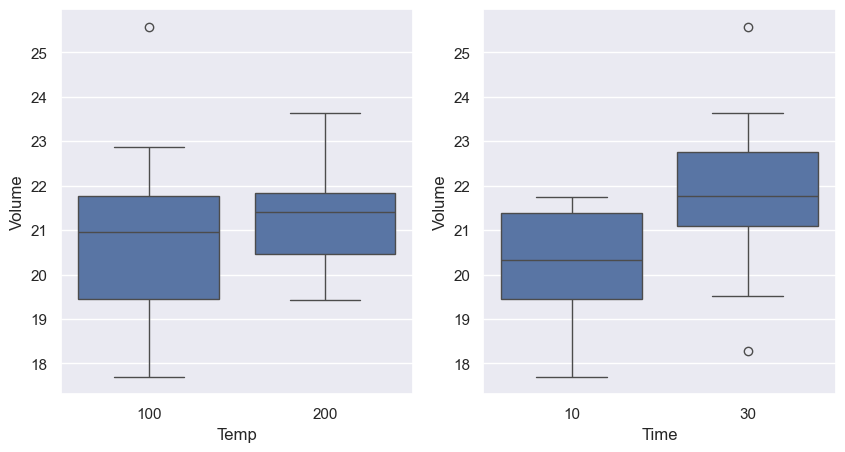

In [5]:
# 箱ひげ図の作成
f, axes = plt.subplots(1, 2, figsize=(10,5))

sns.boxplot(x='Temp', y='Volume', data=data, ax=axes[0])
sns.boxplot(x='Time', y='Volume', data=data, ax=axes[1])

- 帰無仮説（H0）: 温度や時間の条件が合成樹脂の製造量に変化を与えない
- 対立仮説（H1）: 温度や時間の条件が合成樹脂の製造量に変化を与える

In [7]:
# データの製造量の平均
me_all = np.mean(data['Volume'])
print('全体の平均:',me_all)

全体の平均: 21.064619498696487


In [10]:
# 温度条件ごとの製造量の平均
me_Temp_100 = np.mean(data.query('Temp==100')['Volume'])
me_Temp_200 = np.mean(data.query('Temp==200')['Volume'])
print('Temp_100 平均:',me_Temp_100)
print('Temp_200 平均:',me_Temp_200)

Temp_100 平均: 20.81095130951942
Temp_200 平均: 21.318287687873553


In [12]:
# 反応時間ごとの製造量の平均
me_Time_10 = np.mean(data.query('Time==10')['Volume'])
me_Time_30 = np.mean(data.query('Time==30')['Volume'])
print('Time_10 平均:',me_Time_10)
print('Time_30 平均:',me_Time_30)

Time_10 平均: 20.32047783804376
Time_30 平均: 21.80876115934921


In [14]:
# 全体の平方和
squares_all = np.sum((data['Volume']-me_all)**2)
print('全体の平方和:',squares_all)

全体の平方和: 90.77291728168143


In [20]:
# 温度条件の平方和
temp_means_list = [me_Temp_100]*data.query('Temp == 100').shape[0] + \
                  [me_Temp_200]*data.query('Temp == 200').shape[0]

temp_means_expanded = np.array(temp_means_list)

#print(temp_means_expanded)

squares_temp = np.sum((temp_means_expanded - me_all)**2)
print('温度条件の平方和:',squares_temp)

温度条件の平方和: 2.5739020080148745


In [21]:
# 反応時間の平方和
time_means_list = [me_Time_10]*data.query('Time == 10').shape[0] + \
                  [me_Time_30]*data.query('Time == 30').shape[0]

time_means_expanded = np.array(time_means_list)

#print(time_means_expanded)

squares_time = np.sum((time_means_expanded - me_all)**2)
print('反応時間の平方和:',squares_time)

反応時間の平方和: 22.14987244475978


In [22]:
# 誤差の平方和
squares_resid = squares_all - squares_temp - squares_time
print('誤差の平方和:',squares_resid)

誤差の平方和: 66.04914282890678


In [23]:
#自由度
df_all = len(data) - 1
df_temp = 2 - 1     # 温度条件の自由度 = 2 - 1
df_time = 2 - 1     # 反応時間の自由度 = 2 - 1
df_resid = df_all - df_temp - df_time  # 誤差の自由度

print('全体の自由度:',df_all)
print('温度条件の自由度:',df_temp)
print('反応時間の自由度:',df_time)
print('誤差の自由度:',df_resid)

全体の自由度: 39
温度条件の自由度: 1
反応時間の自由度: 1
誤差の自由度: 37


In [24]:
# 分散
variance_all = squares_all/df_all #不偏分散
variance_temp = squares_temp/df_temp
variance_time = squares_time/df_time
variance_resid = squares_resid/df_resid

print('全体の分散（不偏）:',variance_all)
print('温度条件の分散 :',variance_temp)
print('反応時間の分散 :',variance_time)
print('誤差の分散 :',variance_resid)

全体の分散（不偏）: 2.327510699530293
温度条件の分散 : 2.5739020080148745
反応時間の分散 : 22.14987244475978
誤差の分散 : 1.785111968348832


In [25]:
# F比
f_ratio_temp = variance_temp/variance_resid
f_ratio_time = variance_time/variance_resid
print('温度条件のF比 :',f_ratio_temp)
print('反応時間のF比 :',f_ratio_time)

温度条件のF比 : 1.4418714644525332
反応時間のF比 : 12.408113797616663


In [26]:
# p値
p_temp = 1-sp.stats.f.cdf(x=f_ratio_temp, dfn=df_temp, dfd=df_resid)
p_time = 1-sp.stats.f.cdf(x=f_ratio_time, dfn=df_time, dfd=df_resid)
print('温度条件のp値 :',p_temp)
print('反応時間のp値 :',p_time)

温度条件のp値 : 0.23746784737213245
反応時間のp値 : 0.0011555176940120093


因子＼値	     平方和	         自由度	      分散          F比	        p値
---------------------------------------------------------------------------
温度条件	    2.5739	        1 	      2.5739         1.4419     0.2375
反応時間	   22.1499	 	    1 	     22.1499        12.4081     0.0012
誤差	      66.0491	       37 	     1.7851           NaN         NaN

In [27]:
# statsmodelsで二元分散分析を実施
anova_model = smf.ols('Volume ~ Temp + Time', data=data).fit()
sm.stats.anova_lm(anova_model, typ=2)

,sum_sq,df,F,PR(>F)
Temp,2.573902,1.0,1.441871,0.237468
Time,22.149872,1.0,12.408114,0.001156
Residual,66.049143,37.0,NaN,NaN


温度条件のp値は0.237と0.05よりも大きいため、有意差があるとは言い切れない。つまり、温度条件が変わっても製造量に変化を与えない。

反応時間のp値は0.05よりも小さくなったので有意差がある、つまり、反応時間が変わると製造量に変化を与える。